# Quantum Walks on Graphs

Quantum walks are a generalization of classical random walks, where the system's evolution is no longer described by a probability distribution, but rather by a quantum state with amplitudes. Formally, this means that a stochastic process is replaced by unitary dynamics.

## Classical case

If we have a graph $G = (V, E)$, where:
- $V$ - the set of vertices,
- $E$ - the set of edges,

then in the classical case the state of the system is described by a probability vector:
$$
\mathbf{p}(t) = (p_1(t), p_2(t), \dots, p_n(t)),
$$

where $p_i(t)$ is the probability that at time $t$ we are located at vertex $i$.

The evolution of the system is determined by the transition matrix:
$$
\mathbf{p}(t+1) = P \mathbf{p}(t).
$$

$P$ is a matrix where $P_{ij}$ is the probability of moving from vertex $j$ to vertex $i$,
and the product $P \mathbf{p}(t)$ computes the new probability distribution.

## Quantum case

In the quantum case, we no longer work with which state we are in with some probability, but with a superposition with amplitudes.

The state of the system is:
$$
|\psi(t)\rangle = \sum_{v \in V} \alpha_v(t) |v\rangle.
$$

Thus, $|v\rangle$ is the basis state corresponding to vertex $v$, and $\alpha_v(t)$ is the complex amplitude of vertex $v$ at time $t$.
Therefore, $|\alpha_v(t)|^2$ is the probability of being found at vertex $v$ at the moment of measurement.

### Evolution of the system

In the quantum case, the evolution is determined by a unitary operator:
$$
|\psi(t)\rangle = U^t |\psi(0)\rangle.
$$

where $|\psi(0)\rangle$ is the initial state, and $U$ is simply a unitary operator.

In the classical case, different paths contribute by adding probabilities.

In the quantum case, each path contributes to the amplitude:
- amplitudes have both magnitude and phase,
- they can add constructively or destructively.
- - -

## Discrete-Time Quantum Walk

A discrete-time quantum walk is the quantum analogue of a classical walk, where the evolution of the system takes place in discrete steps. A direct transition from a vertex to a neighbor is not unitary, so the system’s state space is enlarged by adding an extra degree of freedom - the direction of motion.

### State space
Let us consider a graph $G = (V, E)$ with $|V| = n$.  

We define two Hilbert spaces:
- $\mathcal{H}_V = \mathrm{span}\{ |v\rangle : v \in V \}$ - the vertex space,
- $\mathcal{H}_C = \mathrm{span}\{ |c\rangle \}$ - the coin (direction) space.

Thus, the total state space is $\mathcal{H} = \mathcal{H}_C \otimes \mathcal{H}_V.$

The basis states are:
$$
|c\rangle \otimes |v\rangle \equiv |c, v\rangle,
$$

- $v \in V$ - the current vertex,
- $c$ - the direction.
  
### General state

The state of the system is a linear combination:
$$
|\psi\rangle = \sum_{v \in V} \sum_{c} \alpha_{c,v} \, |c, v\rangle,
$$

- $\alpha_{c,v} \in \mathbb{C}$ is simply the amplitude of being at vertex $v$ with direction $c$.

One step of evolution (movement to the next vertex) is defined by the unitary operator:
$$
U = S (C \otimes I).
$$

The coin operator $C$ is a unitary operator that acts only on the coin space. It transforms the direction states, creating their superposition.

$$
(C \otimes I)\, |c, v\rangle = (C|c\rangle) \otimes |v\rangle.
$$

Thus, the vertex remains unchanged, but the direction is mixed.

The shift operator $S$ moves the state along the graph using the coin information.

$$
S |c, v\rangle = |c, \, f(v, c)\rangle,
$$

where $f(v, c)$ is the vertex to which the walker moves from $v$ in direction $c$.

Thus, one step with the operator
$$
U = S (C \otimes I)
$$
means:

1. first we apply $C$ and at each vertex distribute the amplitude among all possible directions,

2. then we apply $S$, by which each amplitude component moves to the corresponding neighbor.

A discrete quantum walk works as follows:

- at each step the amplitude is distributed among all directions (coin),
- then each component moves along the graph (shift),
- different paths later interfere.

---

## Example  
Let us consider the simplest case of a discrete-time quantum walk: a 1-dimensional regular line graph with cyclic boundary conditions. Here we use a specific coin model with the Hadamard operator.

![Alt text](qw1d.png)


=== Step t = 0 ===
Nonzero amplitudes:
  |L, 16> : +0.707+0.000j
  |R, 16> : +0.000+0.707j
Probabilities by position:
  x=16: 1.000

=== Step t = 1 ===
Nonzero amplitudes:
  |L, 15> : +0.500+0.500j
  |R, 17> : +0.500-0.500j
Probabilities by position:
  x=15: 0.500
  x=17: 0.500

=== Step t = 2 ===
Nonzero amplitudes:
  |L, 14> : +0.354+0.354j
  |L, 16> : +0.354-0.354j
  |R, 16> : +0.354+0.354j
  |R, 18> : -0.354+0.354j
Probabilities by position:
  x=14: 0.250
  x=16: 0.500
  x=18: 0.250

=== Step t = 3 ===
Nonzero amplitudes:
  |L, 13> : +0.250+0.250j
  |L, 15> : +0.500+0.000j
  |R, 15> : +0.250+0.250j
  |L, 17> : -0.250+0.250j
  |R, 17> : +0.000-0.500j
  |R, 19> : +0.250-0.250j
Probabilities by position:
  x=13: 0.125
  x=15: 0.375
  x=17: 0.375
  x=19: 0.125

=== Step t = 4 ===
Nonzero amplitudes:
  |L, 12> : +0.177+0.177j
  |L, 14> : +0.530+0.177j
  |R, 14> : +0.177+0.177j
  |L, 16> : -0.177-0.177j
  |R, 16> : +0.177-0.177j
  |L, 18> : +0.177-0.177j
  |R, 18> : -0.177+0.530j
  |R, 

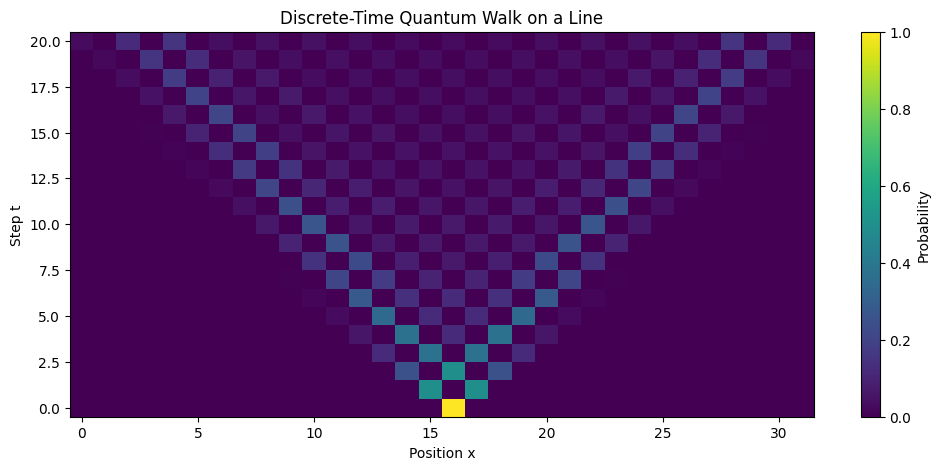

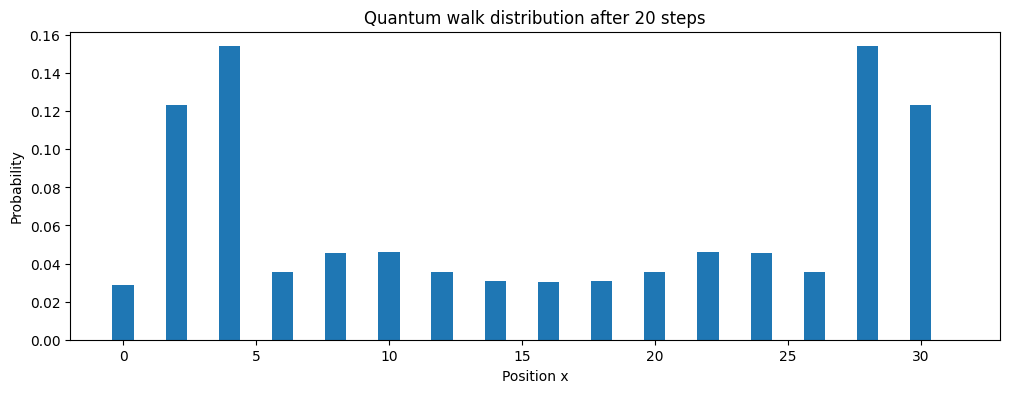


Qiskit circuit:
     ┌───┐┌───┐┌───┐┌────┐┌───┐┌────┐┌───┐┌────┐┌───┐┌────┐┌───┐┌────┐┌───┐»
  c: ┤ H ├┤ S ├┤ H ├┤0   ├┤ H ├┤0   ├┤ H ├┤0   ├┤ H ├┤0   ├┤ H ├┤0   ├┤ H ├»
     └───┘└───┘└───┘│    │└───┘│    │└───┘│    │└───┘│    │└───┘│    │└───┘»
x_0: ───────────────┤1   ├─────┤1   ├─────┤1   ├─────┤1   ├─────┤1   ├─────»
                    │    │     │    │     │    │     │    │     │    │     »
x_1: ───────────────┤2   ├─────┤2   ├─────┤2   ├─────┤2   ├─────┤2   ├─────»
                    │  S │     │  S │     │  S │     │  S │     │  S │     »
x_2: ───────────────┤3   ├─────┤3   ├─────┤3   ├─────┤3   ├─────┤3   ├─────»
                    │    │     │    │     │    │     │    │     │    │     »
x_3: ───────────────┤4   ├─────┤4   ├─────┤4   ├─────┤4   ├─────┤4   ├─────»
     ┌───┐          │    │     │    │     │    │     │    │     │    │     »
x_4: ┤ X ├──────────┤5   ├─────┤5   ├─────┤5   ├─────┤5   ├─────┤5   ├─────»
     └───┘          └────┘     └────┘     └────┘     └────┘

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate

# U = S (C ⊗ I)
# C - Hadamard
# S - shift operators

# The states are |c, x>,
# if c = 0, then we move left
# if c = 1, we move right
# x - position on the line

T = 20  # number of steps
N = 32  # number of positions on the line
CENTER = 16  # initial position


# 1 coin qubit and 5 position qubits
coin = QuantumRegister(1, "c")
pos = QuantumRegister(5, "x")
qc_demo = QuantumCircuit(coin, pos)

DIM = 2 * N  # coin space (2) × position space (N)

# Converts |c,x> into an index in the state vector
def state_index(c, x):
    return c + 2 * x

# Converts an index back into (c,x)
def decode_index(i):
    c = i % 2
    x = i // 2
    return c, x


def apply_coin(qc):
    qc.h(coin[0])

# Shift operators S
# S|0,x> = |0,x-1>
# S|1,x> = |1,x+1>
def build_shift_gate():
    S = np.zeros((DIM, DIM), dtype=complex)  # Initializes the shift matrix for the whole system

    # Goes through both coin states
    for c in [0, 1]:
        # Goes through all positions on the line
        for x in range(N):

            # If coin = 0, move left
            if c == 0:
                x_new = (x - 1) % N

            # If coin = 1, move right
            else:
                x_new = (x + 1) % N

            # Index of the old state |c,x>
            i_old = state_index(c, x)

            # Index of the new state |c,x_new>
            i_new = state_index(c, x_new)

            # Moves the amplitude from the old state to the new one
            S[i_new, i_old] = 1

    
    return UnitaryGate(S, label="S")  # Converts the matrix into a Qiskit unitary gate

shift_gate = build_shift_gate()

def apply_shift(qc):
    qc.append(shift_gate, qc.qubits)

# One quantum walk step
def apply_step(qc):
    apply_coin(qc)
    apply_shift(qc)


# Computes probabilities by position
def position_probabilities(state):
    
    amps = np.array(state.data)  # Gets the amplitudes as an array

    probs = np.zeros(N)  # Prepares an array for the position probabilities

    # Goes through all amplitudes
    for i, a in enumerate(amps):
        _, x = decode_index(i)  # Gets the corresponding position x from the index

        # Adds the probability of this state to position x
        probs[x] += abs(a)**2

    return probs

# Prints the state at one step
def print_state(state, step):
    print(f"\n=== Step t = {step} ===")

    amps = np.array(state.data)

    print("Nonzero amplitudes:")
    for i, a in enumerate(amps):  # Goes through all amplitudes
        if abs(a) > 1e-10:  # if not zero
            c, x = decode_index(i)
            direction = "L" if c == 0 else "R"
            print(f"  |{direction}, {x}> : {a.real:+.3f}{a.imag:+.3f}j")

    probs = position_probabilities(state)

    print("Probabilities by position:")
    for x in range(N):
        if probs[x] > 1e-10:
            print(f"  x={x}: {probs[x]:.3f}")


# Initializes the initial state vector with zeros
psi0 = np.zeros(DIM, dtype=complex)

# Sets the amplitude for the state |0, CENTER> (coin = 0)
psi0[state_index(0, CENTER)] = 1 / np.sqrt(2)

# Sets the amplitude for the state |1, CENTER> (coin = 1) with phase i
psi0[state_index(1, CENTER)] = 1j / np.sqrt(2)

# Creates a Qiskit Statevector object from this vector
state = Statevector(psi0)

history = [position_probabilities(state)]  # stores the full history
print_state(state, 0)

for t in range(1, T + 1):
    H_full = np.zeros((DIM, DIM), dtype=complex)
    H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)  # Define the standard Hadamard for the coin space

    for x in range(N):  # Goes through all positions on the line
        for c_in in [0, 1]:  # Goes through input coin states
            for c_out in [0, 1]:  # Goes through output coin states
                i_in = state_index(c_in, x)  # Finds the index for the state |c_in, x>
                i_out = state_index(c_out, x)  # Finds the index for the state |c_out, x>
                H_full[i_out, i_in] = H[c_out, c_in]  # Inserts the Hadamard matrix into the full one

    state = state.evolve(UnitaryGate(H_full, label="H"))  # Applies the coin operator to the full quantum state
    state = state.evolve(shift_gate)  # Applies the shift operator, which moves left or right

    history.append(position_probabilities(state))  # store the probabilities by position
    print_state(state, t)  # at each step print amplitudes and probabilities



# Draws the "triangle" image
history_array = np.array(history)

plt.figure(figsize=(12, 5))
plt.imshow(history_array, origin="lower", aspect="auto")
plt.colorbar(label="Probability")
plt.xlabel("Position x")
plt.ylabel("Step t")
plt.title("Discrete-Time Quantum Walk on a Line")
plt.show()


# Draws the distribution of the final step
final_probs = history_array[-1]

plt.figure(figsize=(12, 4))
plt.bar(range(N), final_probs)
plt.xlabel("Position x")
plt.ylabel("Probability")
plt.title(f"Quantum walk distribution after {T} steps")
plt.show()



qc_demo = QuantumCircuit(coin, pos)

# initial coin state:
# (|0>+i|1>)/sqrt(2)
qc_demo.h(coin[0])
qc_demo.s(coin[0])

qc_demo.x(pos[4])
for _ in range(T):
    apply_step(qc_demo)

print("\nQiskit circuit:")
print(qc_demo.draw("text"))

## Example 2

Here is a two-dimensional discrete-time quantum walk on an $N \times N$ grid with periodic boundary conditions, where the direction of motion is determined by a four-dimensional coin space. In this example, the Grover coin operator is used, which mixes the four possible directions at each step, while the shift operator moves the particle on the grid according to the coin state: left, right, down, or up.

The position on the grid is encoded using separate registers $x$ and $y$, while the coin space uses 2 qubits, since 4 possible directions are needed. During the simulation, the probability distribution over all grid vertices is calculated and its evolution over several steps is displayed, as well as the final distribution after $T$ steps.

![Alt text](qw2d.png)


=== Step t = 0 ===
Nonzero amplitudes:
  |L, 0, 0> : +0.500+0.000j
  |R, 0, 0> : +0.500+0.000j
  |D, 0, 0> : +0.500+0.000j
  |U, 0, 0> : +0.500+0.000j

=== Step t = 3 ===
Nonzero amplitudes:
  |L, 1, 0> : -0.125+0.000j
  |R, 1, 0> : +0.250+0.000j
  |D, 1, 0> : +0.250+0.000j
  |U, 1, 0> : +0.250+0.000j
  |R, 3, 0> : +0.125+0.000j
  |L, 5, 0> : +0.125+0.000j
  |L, 7, 0> : +0.250+0.000j
  |R, 7, 0> : -0.125+0.000j
  |D, 7, 0> : +0.250+0.000j
  |U, 7, 0> : +0.250+0.000j
  |L, 0, 1> : +0.250+0.000j
  |R, 0, 1> : +0.250+0.000j
  |D, 0, 1> : -0.125+0.000j
  |U, 0, 1> : +0.250+0.000j
  |U, 2, 1> : -0.125+0.000j
  |U, 6, 1> : -0.125+0.000j
  |R, 1, 2> : -0.125+0.000j
  |L, 7, 2> : -0.125+0.000j
  |U, 0, 3> : +0.125+0.000j
  |D, 0, 5> : +0.125+0.000j
  |R, 1, 6> : -0.125+0.000j
  |L, 7, 6> : -0.125+0.000j
  |L, 0, 7> : +0.250+0.000j
  |R, 0, 7> : +0.250+0.000j
  |D, 0, 7> : +0.250+0.000j
  |U, 0, 7> : -0.125+0.000j
  |D, 2, 7> : -0.125+0.000j
  |D, 6, 7> : -0.125+0.000j

=== Step t = 6 ===
Nonz

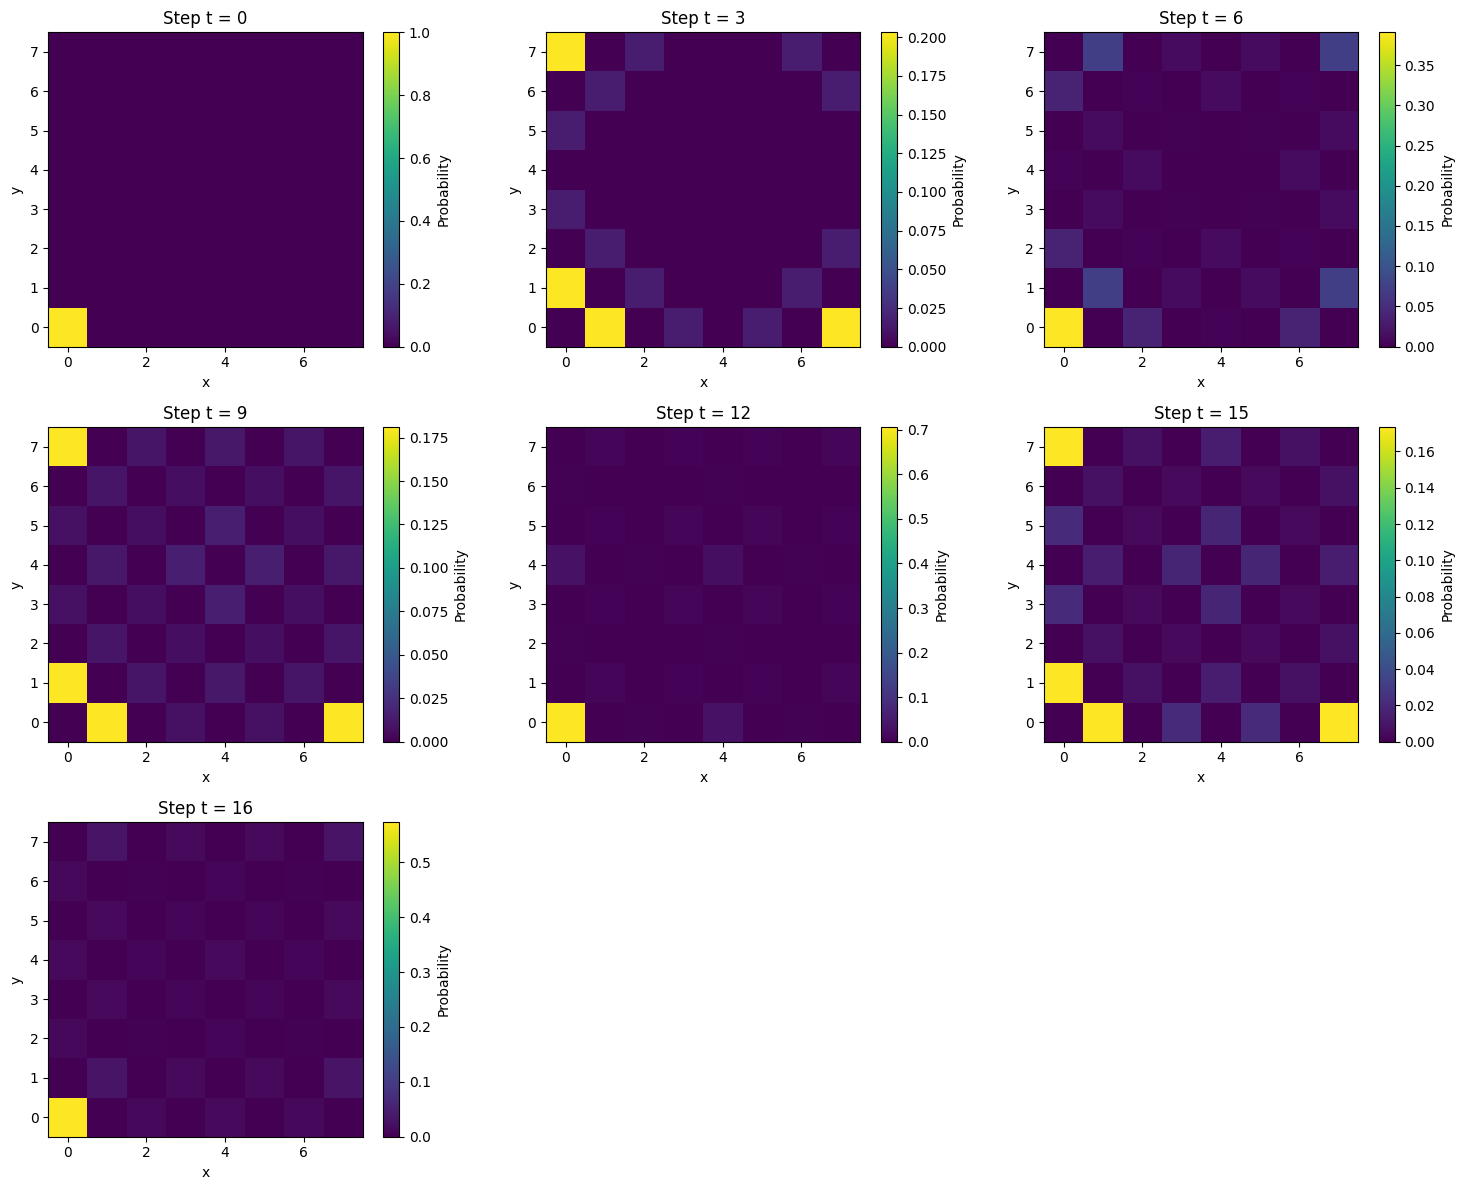


Qiskit circuit:
     ┌───┐┌────┐┌────┐┌────┐┌────┐┌────┐┌────┐┌────┐┌────┐┌────┐┌────┐┌────┐»
c_0: ┤ H ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├┤0   ├»
     ├───┤│    ││    ││    ││    ││    ││    ││    ││    ││    ││    ││    │»
c_1: ┤ H ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├┤1   ├»
     └───┘│    ││    ││    ││    ││    ││    ││    ││    ││    ││    ││    │»
x_0: ─────┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├┤2   ├»
          │    ││    ││    ││    ││    ││    ││    ││    ││    ││    ││    │»
x_1: ─────┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├┤3   ├»
          │  G ││  S ││  G ││  S ││  G ││  S ││  G ││  S ││  G ││  S ││  G │»
x_2: ─────┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├┤4   ├»
          │    ││    ││    ││    ││    ││    ││    ││    ││    ││    ││    │»
y_0: ─────┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├┤5   ├»
          │    ││    ││    ││    ││    ││    ││

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate

# So the 2D space is an N x N grid with periodic boundary conditions.

T = 16  # number of steps
N = 8  # grid size N x N
CENTER_X = N // 2
CENTER_Y = N // 2

# how many qubits are needed to store the coordinates
X_BITS = int(np.log2(N)) 
Y_BITS = int(np.log2(N))

# 2 coin qubits (4 directions), X_BITS qubits for the x coordinate, Y_BITS qubits for the y coordinate
coin = QuantumRegister(2, "c")
xreg = QuantumRegister(X_BITS, "x")
yreg = QuantumRegister(Y_BITS, "y")

qc_demo = QuantumCircuit(coin, xreg, yreg)

DIM = 4 * N * N   # coin space (4) × x space (N) × y space (N)


# Converts |c, x, y> into an index in the state vector
def state_index(c, x, y):
    return c + 4 * (x + N * y)

# Converts an index back into (c, x, y)
def decode_index(i):
    c = i % 4
    tmp = i // 4
    x = tmp % N
    y = tmp // N
    return c, x, y

# Grover coin matrix for the 4-dimensional coin space
G = 0.5 * np.array([
    [-1,  1,  1,  1],
    [ 1, -1,  1,  1],
    [ 1,  1, -1,  1],
    [ 1,  1,  1, -1]
], dtype=complex)


# Creates the full coin operator for the whole system
# It applies the Grover coin to each position (x, y)
def build_coin_gate():
    G_full = np.zeros((DIM, DIM), dtype=complex)  # creates an empty matrix for the whole system
    for y in range(N):  # goes through all grid positions and coin input and output states
        for x in range(N):
            for c_in in range(4):
                for c_out in range(4):
                    i_in = state_index(c_in, x, y)
                    i_out = state_index(c_out, x, y)

                    # Applies the Grover coin only to the coin space, without moving the position (x, y)
                    G_full[i_out, i_in] = G[c_out, c_in]

    return UnitaryGate(G_full, label="G")  # Converts the full matrix into a Qiskit unitary operator

coin_gate = build_coin_gate()

def apply_coin(qc):
    qc.append(coin_gate, qc.qubits)

def build_shift_gate():
    S = np.zeros((DIM, DIM), dtype=complex)  # Creates an empty shift operator matrix for the whole system

    for c in range(4):
        for y in range(N):
            for x in range(N):

                if c == 0:
                    x_new = (x - 1) % N
                    y_new = y

                elif c == 1:
                    x_new = (x + 1) % N
                    y_new = y

                elif c == 2:
                    x_new = x
                    y_new = (y - 1) % N

                else: 
                    x_new = x
                    y_new = (y + 1) % N

                i_old = state_index(c, x, y)
                i_new = state_index(c, x_new, y_new)

                S[i_new, i_old] = 1

    return UnitaryGate(S, label="S")

shift_gate = build_shift_gate()

def apply_shift(qc):
    qc.append(shift_gate, qc.qubits)

# One step
def apply_step(qc):
    apply_coin(qc)
    apply_shift(qc)


# Computes probabilities by position
def position_probabilities(state):
    amps = np.array(state.data)  # Gets all amplitudes of the quantum state as an array
    probs = np.zeros((N, N))  # Creates an empty N x N matrix where the position probabilities will be stored

    for i, a in enumerate(amps):  # Goes through all amplitudes in the full state space
        _, x, y = decode_index(i)
        probs[y, x] += abs(a)**2  # computes the amplitude contribution for each grid position

    return probs


# Prints the most significant amplitudes at one step
def print_state(state, step):
    print(f"\n=== Step t = {step} ===")

    amps = np.array(state.data)
    direction_names = {
        0: "L",
        1: "R",
        2: "D",
        3: "U"
    }
    
    print("Nonzero amplitudes:")
    for i, a in enumerate(amps):
        if abs(a) > 1e-10:
            c, x, y = decode_index(i)
            direction = direction_names[c]
            print(f"  |{direction}, {x}, {y}> : {a.real:+.3f}{a.imag:+.3f}j")


# Initializes the initial position x = 0, y = 0
psi0 = np.zeros(DIM, dtype=complex)

for c in range(4):
    psi0[state_index(c, 0, 0)] = 0.5

state = Statevector(psi0)

# Store the full history
history = [position_probabilities(state)]

print_state(state, 0)

# Evolution
for t in range(1, T + 1):
    state = state.evolve(coin_gate)
    state = state.evolve(shift_gate)

    history.append(position_probabilities(state))

    # print amplitudes only every 3 steps
    if t % 3 == 0:
        print_state(state, t)


final_probs = history[-1]  # Take the probability distribution of the final step

selected_steps = list(range(0, T + 1, 3))  # display every third step
if selected_steps[-1] != T:
    selected_steps.append(T)

num_plots = len(selected_steps)  # Computes how many plots will be needed
cols = 3
rows = int(np.ceil(num_plots / cols))

plt.figure(figsize=(5 * cols, 4 * rows))
for idx, step in enumerate(selected_steps, start=1):
    plt.subplot(rows, cols, idx)
    plt.imshow(history[step], origin="lower", interpolation="nearest")
    plt.colorbar(label="Probability")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Step t = {step}")

plt.tight_layout()
plt.show()


qc_demo.h(coin[0])
qc_demo.h(coin[1])

def initialize_position_register(qc, reg, value, bits):  # Sets the register according to the given value in binary form
    for bit in range(bits):
        # If the specific bit is 1, apply an X gate
        if (value >> bit) & 1:
            qc.x(reg[bit])

initialize_position_register(qc_demo, xreg, 0, X_BITS)
initialize_position_register(qc_demo, yreg, 0, Y_BITS)
for _ in range(T):
    apply_step(qc_demo)

print("\nQiskit circuit:")
print(qc_demo.draw("text"))

## Continuous-Time Quantum Walk (CTQW)

In a discrete-time quantum walk (DTQW), the system evolves in steps using a coin operator and a shift operator. In contrast, in a continuous-time quantum walk, there are no such steps, and the system evolves continuously in time, similarly to waves in physics.

In the DTQW case, at each step we performed:
- coin (chooses the direction)
- shift (moves along the graph)

In the CTQW case:
- there is no coin
- there are no discrete steps
- the motion is determined entirely by the graph itself

### Main formula

$$
|\psi(t)\rangle = e^{-iHt} |\psi(0)\rangle
$$

Unlike DTQW, the time $t$ is not a “step,” but a continuous quantity:
- $t = 0, 0.1, 0.2, \dots$

Simply put, the Hamiltonian $H$ tells us how the system changes in time.

In the CTQW case:
- the Hamiltonian is built from the graph
- it determines to which vertices the amplitude can move

## Example of CTQW
Let us consider a continuous-time quantum walk on a cycle with 16 vertices, where each vertex is connected to two neighboring vertices. The evolution of the system is determined by the Hamiltonian corresponding to the adjacency matrix of this graph, and the evolution takes place continuously in time.

To implement this model in a quantum circuit, we use the Quantum Fourier Transform (QFT), which allows us to move to a basis in which the Hamiltonian becomes diagonal. In this basis, the evolution is implemented as a simple application of phases, and then, using the inverse QFT, the system is returned to the position space.

![Alt text](ctqw.png)


=== Time t = 0.00 ===
Nonzero amplitudes:
  |8> : +1.000+0.000j
Probabilities by vertices:
  x=8: 1.000

=== Time t = 2.00 ===
Nonzero amplitudes:
  |0> : +0.008-0.000j
  |1> : -0.000+0.014j
  |2> : -0.049-0.000j
  |3> : -0.000-0.132j
  |4> : +0.281-0.000j
  |5> : +0.000+0.430j
  |6> : -0.364+0.000j
  |7> : +0.000+0.066j
  |8> : -0.397+0.000j
  |9> : +0.000+0.066j
  |10> : -0.364+0.000j
  |11> : +0.000+0.430j
  |12> : +0.281-0.000j
  |13> : -0.000-0.132j
  |14> : -0.049-0.000j
  |15> : -0.000+0.014j
Probabilities by vertices:
  x=0: 0.000
  x=1: 0.000
  x=2: 0.002
  x=3: 0.017
  x=4: 0.079
  x=5: 0.185
  x=6: 0.133
  x=7: 0.004
  x=8: 0.158
  x=9: 0.004
  x=10: 0.133
  x=11: 0.185
  x=12: 0.079
  x=13: 0.017
  x=14: 0.002
  x=15: 0.000

=== Time t = 5.00 ===
Nonzero amplitudes:
  |0> : +0.636-0.000j
  |1> : -0.000-0.075j
  |2> : -0.193+0.000j
  |3> : +0.000+0.357j
  |4> : -0.156-0.000j
  |5> : +0.000+0.029j
  |6> : -0.267+0.000j
  |7> : +0.000-0.039j
  |8> : -0.243+0.000j
  |9> : -0.0

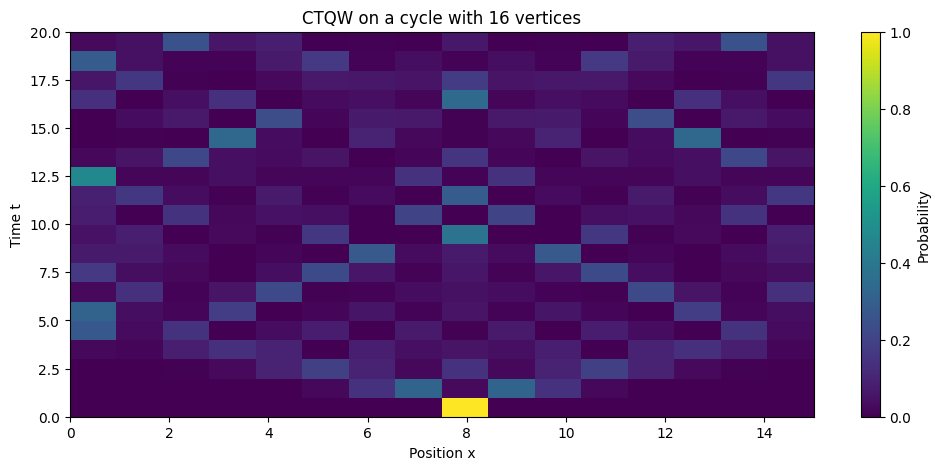

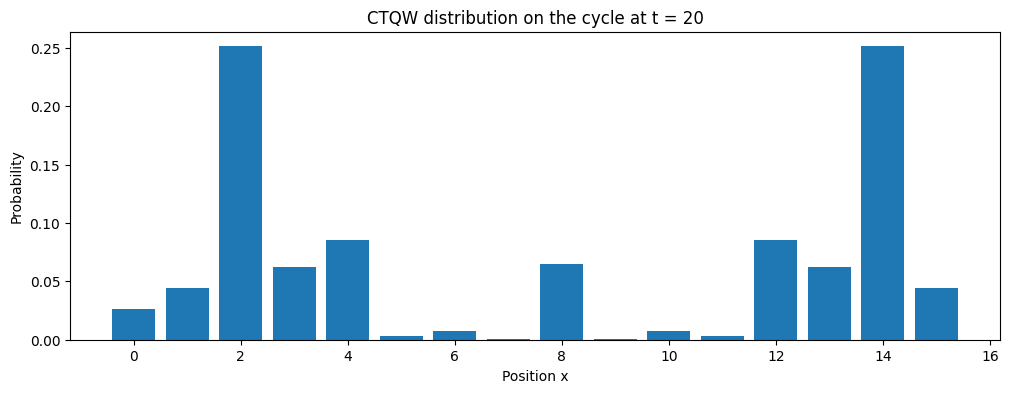

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import QFTGate, DiagonalGate
from qiskit.quantum_info import Statevector

# 16 vertices = 4 qubits
# The cycle Hamiltonian A is diagonalizable in the Fourier basis
# A = F^† diag(lambda_k) F
# lambda_k = 2 cos(2 pi k / N)
# exp(-i A t) = F^† diag(exp(-i lambda_k t)) F

T_MAX = 20  # maximum time
NUM_T = 20  # how many time points we observe
N = 16  # number of vertices in the cycle
NUM_QUBITS = 4
START_VERTEX = 8


# Initializes the position register to a given vertex
def initialize_position_register(qc, reg, value, bits):
    for bit in range(bits):
        if (value >> bit) & 1:
            qc.x(reg[bit])


# Computes probabilities for each vertex
def position_probabilities(state):
    amps = np.array(state.data)
    probs = np.abs(amps) ** 2
    return probs


# Prints the state at a specific time
def print_state(state, t):
    print(f"\n=== Time t = {t:.2f} ===")

    amps = np.array(state.data)

    print("Nonzero amplitudes:")
    for x, a in enumerate(amps):
        if abs(a) > 1e-10:
            print(f"  |{x}> : {a.real:+.3f}{a.imag:+.3f}j")

    probs = position_probabilities(state)

    print("Probabilities by vertices:")
    for x in range(N):
        if probs[x] > 1e-10:
            print(f"  x={x}: {probs[x]:.3f}")


# Builds the CTQW evolution circuit for time t
def build_ctqw_circuit(t):
    pos = QuantumRegister(NUM_QUBITS, "x")
    qc = QuantumCircuit(pos)

    # With QFT on all qubits, we move to the Fourier basis,
    # because in that basis the Hamiltonian becomes diagonal
    qc.append(QFTGate(NUM_QUBITS), pos[:])

    # Formula for the eigenvalues of the cycle adjacency matrix
    lambdas = np.array([2 * np.cos(2 * np.pi * k / N) for k in range(N)])

    # Formula for computing the diagonal evolution phases
    phases = np.exp(-1j * lambdas * t)

    # Adds a diagonal gate operator to the circuit
    qc.append(DiagonalGate(phases), pos[:])

    # Go back to the standard position basis
    qc.append(QFTGate(NUM_QUBITS).inverse(), pos[:])

    return qc


# Position register
pos = QuantumRegister(NUM_QUBITS)

# Initial circuit
qc_init = QuantumCircuit(pos)
initialize_position_register(qc_init, pos, START_VERTEX, NUM_QUBITS)

# Initial state
state0 = Statevector.from_instruction(qc_init)
print_state(state0, 0.0)

# Time points
times = np.linspace(0, T_MAX, NUM_T)  # creates a list from 0 to the chosen time, in NUM_T intervals

# Store the history
history = []

for t in times:
    qc_t = build_ctqw_circuit(t)
    state_t = state0.evolve(qc_t)
    history.append(position_probabilities(state_t))

# Print a few selected times
for t in [2.0, 5.0, 10.0, 15.0, 20.0]:
    qc_t = build_ctqw_circuit(t)
    state_t = state0.evolve(qc_t)
    print_state(state_t, t)

history_array = np.array(history)

# Heatmap
plt.figure(figsize=(12, 5))
plt.imshow(
    history_array,
    origin="lower",
    aspect="auto",
    extent=[0, N - 1, 0, T_MAX],
    interpolation="nearest"
)
plt.colorbar(label="Probability")
plt.xlabel("Position x")
plt.ylabel("Time t")
plt.title("CTQW on a cycle with 16 vertices")
plt.show()

# Final distribution
final_probs = history_array[-1]

plt.figure(figsize=(12, 4))
plt.bar(range(N), final_probs)
plt.xlabel("Position x")
plt.ylabel("Probability")
plt.title(f"CTQW distribution on the cycle at t = {T_MAX}")
plt.show()

## References

This material is based on:
A. Childs, *Lecture 14: Quantum Walks*, University of Maryland, 2008.  
https://www.cs.umd.edu/~amchilds/teaching/w08/l14.pdf